<a href="https://colab.research.google.com/github/egortens1a/AI_ML_DC/blob/master/lab4var6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### BernoulliNB
### 20 Newsgroups Dataset
### Векторизация текста с бинаризацией

In [1]:
from sklearn.datasets import fetch_20newsgroups

# Загрузка данных (можно выбрать подмножество категорий или все)
categories = ['sci.space', 'rec.sport.baseball', 'comp.graphics']
newsgroups = fetch_20newsgroups(subset='all', categories=categories, shuffle=True, random_state=42)

X = newsgroups.data
y = newsgroups.target

In [2]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(binary=True, max_features=1000)  # Ограничимся 1000 слов
X_vec = vectorizer.fit_transform(X)

In [3]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.3, random_state=42)

# Обучение модели
model = BernoulliNB()
model.fit(X_train, y_train)

BernoulliNB()

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.8782412626832018
Precision (macro): 0.8936871413057353
Recall (macro): 0.8784242081628154
F1-score (macro): 0.8805947780250993


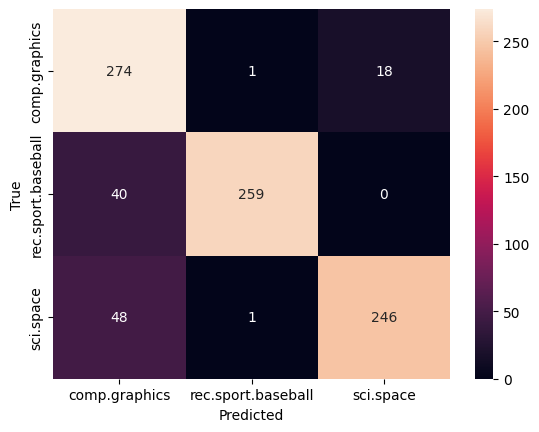

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=newsgroups.target_names, yticklabels=newsgroups.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Выводы
## Качество модели:

- Метрики (Accuracy, F1) показывают, насколько хорошо модель классифицирует тексты.

- Если точность низкая, можно попробовать увеличить max_features или настроить CountVectorizer (например, добавить стоп-слова, N-граммы).

## Особенности BernoulliNB:
- Хорошо работает с бинарными признаками.

- Быстро обучается, но может уступать в точности более сложным моделям (например, MultinomialNB с частотной векторизацией).

## Предобработка:

- Бинаризация упрощает признаки, но теряет информацию о частоте слов.

- Для текстов также можно пробовать TF-IDF векторизацию.